# 교과서에서 전처리·탐색한 `weather2023.xlsx`를 이용하여  
기온(temp), 풍속(wind), 습도(humi), 전운량(cloud)으로  
합계 일조시간(sunshine)을 예측하는 선형회귀 모델을 만드는 실습이다.

<탐구질문> 오늘의 기온, 풍속,습도, 전운량을 알면 일조시간을 예측할 수 있을까?

STEP 1. 라이브러리 불러오기와 데이터 확인


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

weather = pd.read_excel('../datas/weather2023.xlsx', index_col='date')
weather.isnull().sum()
weather.drop(['rain', 'location', 'loc_name'], axis=1, inplace=True)
weather.head()

,temp,wind,humi,sunshine,cloud
date,,,,,
2023-01-01,-0.2,2.7,55.0,9.0,1.3
2023-01-02,-4.5,2.5,46.0,9.1,0.0
2023-01-03,-5.0,1.8,49.0,9.1,0.0
2023-01-04,-1.8,1.9,51.0,8.7,1.9
2023-01-05,-1.6,1.6,58.1,4.7,3.6


STEP2. 입력 데이터 X와 정답 y 정하기

In [76]:
# 입력과 정답을 정하기
# X='temp', 'wind', 'humi', 'cloud' 4개 특성
# y=sunshine

X = weather[['temp', 'wind', 'humi', 'cloud']]
y = weather['sunshine']
print(X.head())
print(y.head())

            temp  wind  humi  cloud
date                               
2023-01-01  -0.2   2.7  55.0    1.3
2023-01-02  -4.5   2.5  46.0    0.0
2023-01-03  -5.0   1.8  49.0    0.0
2023-01-04  -1.8   1.9  51.0    1.9
2023-01-05  -1.6   1.6  58.1    3.6
date
2023-01-01    9.0
2023-01-02    9.1
2023-01-03    9.1
2023-01-04    8.7
2023-01-05    4.7
Name: sunshine, dtype: float64


STEP3. 훈련데이터와 테스트테이터로 분리하기

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('훈련 데이터: ', X_train.shape)
print('테스트 데이터: ', X_test.shape)

훈련 데이터:  (144, 4)
테스트 데이터:  (37, 4)


STEP4. 선형회귀 모델 학습하기

In [78]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.12, 0.2 ,-0.06,-1.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['temp','wind','humi','cloud']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.48
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


STEP5. 테스트 데이터 예측하기

In [79]:
pred = model.predict(X_test)
result = pd.DataFrame({
    'original_index': y_test.index,
    'actual': y_test.values,
    'predicted': pred
})
print(result.head(10))

  original_index  actual  predicted
0     2023-01-20     8.7  10.220608
1     2023-02-12     2.0   2.696020
2     2023-06-03    13.3  10.724790
3     2023-03-20    10.0   8.865658
4     2023-05-26    10.7   5.592091
5     2023-01-16     8.8   6.580402
6     2023-01-25     9.4   8.029100
7     2023-03-10     9.6  11.635115
8     2023-04-24     7.8   7.349061
9     2023-04-29     0.8   0.118703


STEP6. 모델 성능 평가하기

In [80]:
from sklearn.metrics import r2_score, mean_absolute_error

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print('MAE: ', mae)
print('R2: ', r2)


MAE:  1.4872732719755144
R2:  0.7737787722337529


STEP7. 실제값과 예측값 시각화하기


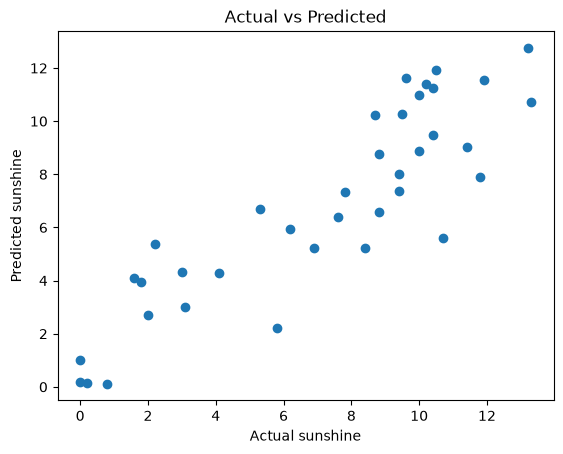

In [81]:
plt.scatter(y_test, pred)
plt.xlabel('Actual sunshine')
plt.ylabel('Predicted sunshine')
plt.title('Actual vs Predicted')
plt.show()

STEP 8. 새로운 날씨 데이터 예측하기
 - X값 중 하나 이상을 바꾸어 새로운 날씨의 일조 시간 예측

In [82]:
new_weather = pd.DataFrame({
    'temp': [20.0],
    'wind': [2.5],
    'humi': [60.0],
    'cloud': [4.0],
})

new_pred = model.predict(new_weather)

print('예측 일조시간:', new_pred[0])

예측 일조시간: 8.46728864137906


STEP 9. 특성을 하나만 쓸 때와 여러개 쓸때 비교

In [108]:
from sklearn.linear_model import LinearRegression

X1 = weather[['cloud']]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

pred1 = model1.predict(X1_test)

mae1 = mean_absolute_error(y1_test, pred1)
r21 = r2_score(y1_test, pred1)

print('cloud만 사용한 MAE:', mae1)
print('cloud만 사용한 R2:', r21)
print()
print('4개 특성 사용 MAE:', mae)
print('4개 특성 사용 R2:', r2)

cloud만 사용한 MAE: 1.983557053359193
cloud만 사용한 R2: 0.6335007834575184

4개 특성 사용 MAE: 1.4872732719755144
4개 특성 사용 R2: 0.7737787722337529


STEP10. 랜덤포레스트 회귀와 비교

In [100]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error
model2 = RandomForestRegressor()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

result2 = pd.DataFrame({
    'original_index': y_test.index,
    'actual': y_test.values,
    'predicted': pred2
})
print(result2.head())

mae2 = mean_absolute_error(y_test, pred2)
mse2 = mean_squared_error(y_test, pred2)
rmse2_np = np.sqrt(mse2)
rmse2_sklearn = root_mean_squared_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print('mae:', mae2)
print('r^2:', r22)
print(mse2)

  original_index  actual  predicted
0     2023-01-20     8.7      9.420
1     2023-02-12     2.0      2.971
2     2023-06-03    13.3     11.260
3     2023-03-20    10.0      8.216
4     2023-05-26    10.7      5.982
mae: 1.369837837837838
r^2: 0.8037673535279414
3.1254600000000012
